<a href="https://colab.research.google.com" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(135deg,#1a237e,#1565c0);
     padding:36px 32px 28px; border-radius:10px; margin-bottom:4px;">
<h1 style="color:#fff;font-family:'Georgia',serif;font-size:2em;margin:0 0 6px 0;">
    Na Emission Spectrum</h1>
<h3 style="color:#90caf9;font-family:'Georgia',serif;font-weight:normal;
           font-size:1.15em;margin:0 0 14px 0;">
    Chemistry 76 &nbsp;·&nbsp; Peak Finding
</h3>
<div style="color:#bbdefb;font-size:0.9em;line-height:1.8;">
    <b style="color:#fff;">What this notebook does:</b>
    Loads your raw scan, identifies all emission peaks, separates Hg calibration
    lines from Na candidates, removes known lamp impurities, and delivers two
    CSV files: a Na peak list (raw observed wavelengths only) and the Hg
    calibration pairs. The wavelength corrections and wavenumber conversion
    are yours to do in your analysis.
</div></div>


## How to use this notebook

Run every cell **in order** using **Shift + Enter**.

At the end, two files are saved to your Google Drive and downloaded:
- `na_peaks.csv` — your Na emission peaks (λ_obs in Å, intensity in V)
- `hg_peaks.csv` — the Hg calibration pairs (λ_obs observed + λ_true literature)

> Do not change any constants or the data URL.


## Step 1 — Import libraries

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks
from scipy.stats import linregress
from scipy.optimize import brentq
from IPython.display import display
import os

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 11, 'axes.titlesize': 12,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'font.family': 'serif',
})
print("✓  Libraries loaded.")


✓  Libraries loaded.


## Step 2 — Pre-configured constants

All values below are **locked**. Do not change them.

In [12]:
PEAK_HEIGHT    = 0.20
MIN_SEPARATION = 2.0
HG_MATCH_TOL   = 5.0
BOGUS_TOL      = 4.0

R_NA   = 109734.698
A_CORR = 2.6343e-4
B_CORR = 0.07621

HG_TRUE = np.array([3125.67, 3131.55, 3650.15, 4046.56,
                     4358.33, 5460.74, 5769.60, 5790.66])

BOGUS = np.array([
    # Standard lamp impurities (lab manual):
    3342, 4159, 4164, 4182, 4191, 4199, 4201, 4252, 4260,
    4267, 4272, 4300, 4316, 4334, 4345, 4366,
    # NOTE: 4425 removed — it falls within 4A of 9S->3P at 4424.7 Å
    4511, 4522, 4554, 4596, 4629, 4703, 4935, 5163, 5188, 5222,
    5496, 5559, 5573, 5607, 5651,
    # Secondary Hg multiplet lines (not used for calibration):
    3024.0, 3027.0, 3135.0, 3655.0, 3663.0, 4078.0,
    # Ne contamination:
    5078.5, 5852.5, 5944.8,
    5938.8,   # Ne line (6 Å from 5944.8 — needs explicit entry for this scan)
    5072.7, 5070.9,  # near-Ne region
    # Bright lamp line adjacent to D-lines:
    5899.2,
    # Scan-specific spurious lines (no valid Na assignment):
    6163.2, 6156.4,  # beyond useful range
    5750.3,          # unidentified lamp line
    5526.3,          # unidentified
    5083.0,          # near-Ne region
    4919.5, 4906.1, 4823.9, 4785.4,  # unidentified impurities
])

NEAR_HG = np.array([5758., 5760., 5762., 5764., 5766.,
                     5793., 5795., 5797., 5799., 5801.])

ZONE_LO = 4100.0;  ZONE_HI = 4640.0
WHITELIST_ZONE = np.array([
    # 4D->3P doublet:
    5690.502, 5685.203,
    # 5D->3P doublet:
    4986.543, 4982.004,
    # 7S->3P:
    4754.849,
    # 6D->3P doublet:
    4671.886, 4668.106,
    # 7D->3P doublet:
    4500.740, 4496.001,
    # 9S->3P doublet:
    4424.735, 4420.436,
    # 8D->3P cluster + adjacent:
    4400.520, 4396.741, 4394.721, 4392.701, 4389.682, 4386.903,
    # 10S->3P:
    4349.850,
    # 9D->3P cluster:
    4329.474, 4327.475, 4325.715, 4322.176,
    # 11S->3P cluster:
    4292.002, 4289.982, 4287.183, 4285.423, 4282.404,
    # 10D->3P:
    4279.384, 4277.105,
    # 12S->3P:
    4253.949,
    # 11D->3P cluster:
    4246.391, 4243.611, 4241.592, 4239.072, 4237.293,
    # 13S->3P:
    4223.415,
    # 12D->3P cluster:
    4220.396, 4217.636, 4214.597, 4211.838, 4209.818,
    # high-n:
    4207.778, 4205.779,
    # high-n cluster:
    4176.545, 4174.025, 4172.006, 4170.246,
    # high-n:
    4153.089, 4151.090,
    # UV:
    4081.004,
])
WHITELIST_TOL = 1.5   # tight — exact-position matching

I_UV  = 0.20;  I_MID = 0.24;  I_NIR = 0.25

print(f"✓  Constants: BOGUS = {len(BOGUS)} entries, R_Na = {R_NA} cm\u207b\u00b9")


✓  Constants: BOGUS = 53 entries, R_Na = 109734.698 cm⁻¹


## Step 3 — Load your raw data

In [13]:
url     = "https://drive.google.com/file/d/1ShworhVHK0_41zKTFXamzO19e-Xg3f2h/view?usp=sharing"
file_id = url.split('/')[-2]
dl_url  = f"https://drive.google.com/uc?id={file_id}"

dataframe  = pd.read_csv(dl_url, names=["Wavelength (A)", "Intensity"], sep='\t')
data       = dataframe.to_numpy()
wavelength = data[:, 0]
intensity  = data[:, 1]

print(f"✓  Data loaded: {len(wavelength):,} points")
print(f"   Range : {wavelength[0]:.1f} – {wavelength[-1]:.1f} Å")
print(f"   Signal: {intensity.min():.4f} – {intensity.max():.4f} V")
print(f"   Step  : {np.mean(np.diff(wavelength)):.4f} Å/point")

✓  Data loaded: 12,577 points
   Range : 3000.2 – 6202.1 Å
   Signal: -0.0928 – 10.0000 V
   Step  : 0.2546 Å/point


## Step 4 — Raw spectrum overview

Check: flat baseline ~0.05–0.08 V, bright peaks saturating at 10 V.

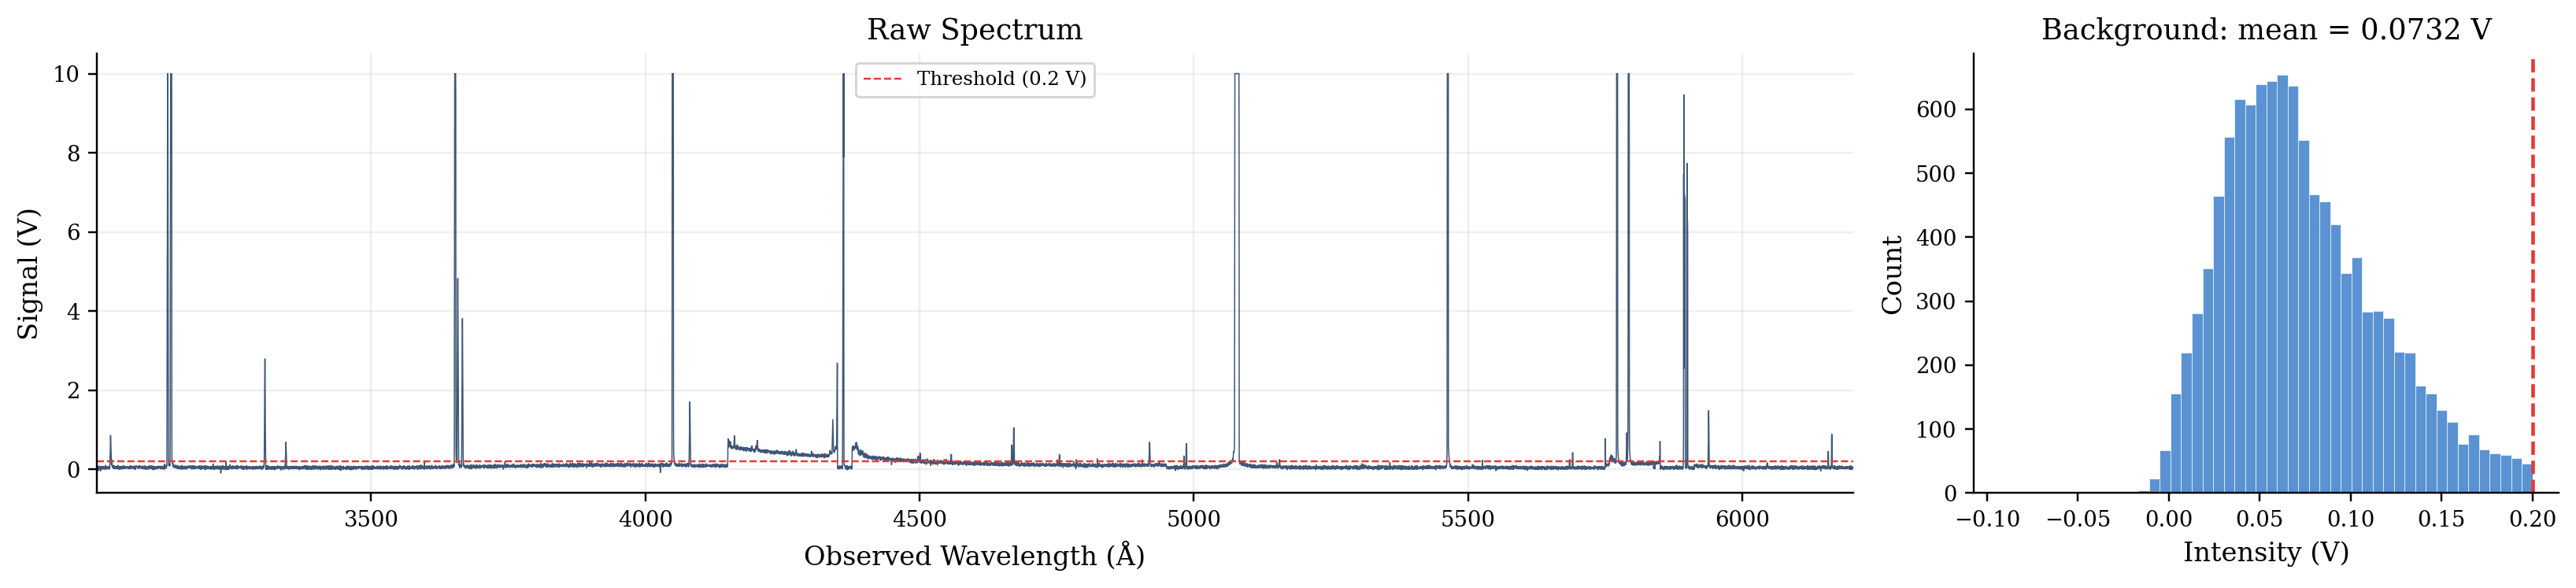

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 3.5),
                                gridspec_kw={'width_ratios': [3,1]})
ax1.plot(wavelength, intensity, color='#1e3a5f', lw=0.5, alpha=0.85, rasterized=True)
ax1.axhline(PEAK_HEIGHT, color='#e53935', lw=0.8, ls='--', label=f'Threshold ({PEAK_HEIGHT} V)')
ax1.set_xlabel('Observed Wavelength (Å)'); ax1.set_ylabel('Signal (V)')
ax1.set_title('Raw Spectrum'); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.2)
ax1.set_xlim(wavelength[0], wavelength[-1])
background = intensity[intensity < PEAK_HEIGHT]
ax2.hist(background, bins=50, color='#1565c0', alpha=0.7, edgecolor='white', lw=0.3)
ax2.axvline(PEAK_HEIGHT, color='#e53935', lw=1.5, ls='--')
ax2.set_xlabel('Intensity (V)'); ax2.set_ylabel('Count')
ax2.set_title(f'Background: mean = {background.mean():.4f} V')
plt.tight_layout(); plt.show()


## Step 5 — Automatic peak detection

Finds every local maximum ≥ 0.20 V with separation ≥ 2.0 Å.

In [15]:
step         = np.mean(np.diff(wavelength))
min_dist_pts = int(MIN_SEPARATION / step)
peak_idx, _  = find_peaks(intensity, height=PEAK_HEIGHT, distance=min_dist_pts)
pk_wl        = wavelength[peak_idx]
pk_sig       = intensity[peak_idx]
print(f"Step size:   {step:.4f} Å/point")
print(f"Peaks found: {len(pk_wl)} above {PEAK_HEIGHT} V")


Step size:   0.2546 Å/point
Peaks found: 219 above 0.2 V


## Step 6 — Separate Hg and Na peaks

Any peak within 5 Å of a literature Hg wavelength is a calibration line. You will apply the calibration fit in your analysis.

In [16]:
nearest_hg = np.array([np.min(np.abs(w - HG_TRUE)) for w in pk_wl])
is_hg      = nearest_hg < HG_MATCH_TOL
hg_obs_wl  = pk_wl[is_hg];   hg_obs_sig = pk_sig[is_hg]
na_wl_all  = pk_wl[~is_hg];  na_sig_all = pk_sig[~is_hg]

print(f"Hg calibration peaks : {is_hg.sum()}")
print(f"Na candidates (raw)  : {(~is_hg).sum()}")
print()
print(f"  {'Detected λ_obs (Å)':>20}  {'HG_TRUE (Å)':>12}  {'Δλ (Å)':>8}")
print("  " + "─"*44)
for w in sorted(hg_obs_wl):
    t = HG_TRUE[np.argmin(np.abs(w - HG_TRUE))]
    print(f"  {w:>20.3f}  {t:>12.2f}  {w-t:>+8.3f}")


Hg calibration peaks : 11
Na candidates (raw)  : 208

    Detected λ_obs (Å)   HG_TRUE (Å)    Δλ (Å)
  ────────────────────────────────────────────
              3128.974       3131.55    -2.576
              3135.273       3131.55    +3.723
              3653.249       3650.15    +3.099
              4049.990       4046.56    +3.430
              4361.688       4358.33    +3.358
              5463.027       5460.74    +2.287
              5766.667       5769.60    -2.933
              5768.666       5769.60    -0.934
              5771.686       5769.60    +2.086
              5789.602       5790.66    -1.058
              5792.881       5790.66    +2.221


## Step 7 — Remove impurities and apply zone filter

Impurities, secondary Hg lines, Ne contamination lines, and one unassignable lamp line at 5899.2 Å are removed. The dense 4100–4640 Å region is filtered to a whitelist of known Na assignments.

## Step 8 — Annotated spectrum

- 🔴 **Red ▼** — Hg calibration lines
- 🟠 **Orange ▲** — your clean Na peaks
- ✗ **Grey** — excluded lines

The D-line zoom should show exactly **two** orange peaks near 5890–5896 Å.


In [17]:
is_bogus   = np.array([np.min(np.abs(w - BOGUS)) < BOGUS_TOL for w in na_wl_all])
is_near_hg = np.array([np.min(np.abs(w - NEAR_HG)) < 3.0      for w in na_wl_all])

# D-line protection: prevents BOGUS window around 5899.2 from removing D1 at ~5895.96 Å
is_dline_all = (na_wl_all > 5880) & (na_wl_all < 5910)
is_bogus[is_dline_all & (na_wl_all < 5898)] = False

in_zone  = (na_wl_all >= ZONE_LO) & (na_wl_all <= ZONE_HI)
is_dline = (na_wl_all > 5880) & (na_wl_all < 5910)
near_wl  = np.array([np.min(np.abs(w - WHITELIST_ZONE)) < WHITELIST_TOL for w in na_wl_all])

uv_r  =  na_wl_all < 3500
mid_r = ((na_wl_all >= 3500) & (na_wl_all < 4100)) | \
        ((na_wl_all >= 4640) & (na_wl_all < 5600))
nir_r =  na_wl_all >= 5600

keep_s = np.zeros(len(na_wl_all), dtype=bool)
keep_s[is_dline]              = True
keep_s[~in_zone&~is_dline&uv_r]  = na_sig_all[~in_zone&~is_dline&uv_r]  >= I_UV
keep_s[~in_zone&~is_dline&mid_r] = na_sig_all[~in_zone&~is_dline&mid_r] >= I_MID
keep_s[~in_zone&~is_dline&nir_r] = na_sig_all[~in_zone&~is_dline&nir_r] >= I_NIR
keep_s[in_zone] = near_wl[in_zone]

is_clean     = ~is_bogus & ~is_near_hg & keep_s
na_wl_clean  = na_wl_all[is_clean]
na_sig_clean = na_sig_all[is_clean]

print(f"Na raw:           {len(na_wl_all)}")
print(f"  bogus/Ne:      -{is_bogus.sum()}")
print(f"  near-Hg:       -{(~is_bogus & is_near_hg).sum()}")
print(f"  zone filtered: -{(~is_bogus & ~is_near_hg & ~keep_s).sum()}")
print(f"  CLEAN:          {is_clean.sum()}  (expected: 53)")


Na raw:           208
  bogus/Ne:      -78
  near-Hg:       -5
  zone filtered: -72
  CLEAN:          53  (expected: 53)


## Step 9 — Doublets and suspicious peaks

---

### Doublets

Every Na emission transition in this spectrum produces two closely spaced lines.
This happens because spin-orbit coupling splits each $nL$ level ($L > 0$) into
two sub-levels with total angular momentum $J = L \pm \tfrac{1}{2}$. Both the
upper and lower levels are split, so every transition produces a **doublet** —
two lines separated by typically 6–20 cm⁻¹.

**Identifying doublet pairs in your list** (do this after converting to wavenumbers):

Scan your sorted peak list for adjacent pairs satisfying all three criteria:
1. Separated by **8–25 cm⁻¹** in wavenumber
2. **Adjacent** in the sorted list — no unrelated peak between them
3. **Similar intensity** — both components are usually within a factor of ~2

**What to report for each doublet:**
$$\tilde{\nu}_\text{mean} = \frac{\tilde{\nu}_1 + \tilde{\nu}_2}{2} \qquad
\Delta\tilde{\nu}_\text{split} = |\tilde{\nu}_1 - \tilde{\nu}_2|$$

Use $\tilde{\nu}_\text{mean}$ for all Δ-table matching and line assignment.
Report $\Delta\tilde{\nu}_\text{split}$ as the spin-orbit energy splitting for
that orbital.

**Some peaks will have no resolvable partner** in this dataset. This can happen
because the partner component falls below the detection threshold, or because the
splitting is smaller than the instrument step size (~0.25 Å) and both components
appear as one broadened peak. When you cannot find a partner within 25 cm⁻¹,
use the single observed $\tilde{\nu}$ directly for assignment — do not spend
time looking for a partner that is not there.

---

### The Na D-lines — start here

The two brightest peaks in your list near 5890–5896 Å are the **sodium D-lines**:
the resolved doublet of the $3P \to 3S$ transition. Their splitting of \~6.6 cm⁻¹
is the spin-orbit splitting of the $3P$ level. These are your anchor — assign
them first, derive $\delta_{3S}$ from their mean wavenumber, and work outward
from there.

---

### Suspicious peaks — mark as unassigned

A small number of peaks in your list are real lamp emission features but will
not match any entry in the Δ table. When a peak has no plausible Δ-table match
after careful checking, mark it **unassigned** and move on — it does not affect
your determination of $R_\text{Na}$ or the ionization energy.

> **Note on S-series:** The S-series assignment becomes unreliable above n=10 in this scan because S and D lines crowd together below 4300 Å. Stop the S-series chain when your calculated δ_S drifts far from the value you found for 6S and 7S, or when consecutive S and D lines are less than ~300 cm⁻¹ apart. For this data you should find **4 S-lines**: 6S, 7S, 9S, and 10S (8S falls outside the scan range).


## Step 10 — Save and download

Files are saved to `My Drive / Chem76_Na_Lab /` and downloaded to your computer.
Run this cell last.


In [18]:
sort_na = np.argsort(na_wl_clean)[::-1]

na_df = pd.DataFrame({
    'peak_num':     range(1, is_clean.sum() + 1),
    'lambda_obs_A': np.round(na_wl_clean[sort_na], 3),
    'intensity_V':  np.round(na_sig_clean[sort_na], 4),
})

hg_true_m = np.array([HG_TRUE[np.argmin(np.abs(w - HG_TRUE))] for w in hg_obs_wl])
seen = {}
for obs, true in zip(hg_obs_wl, hg_true_m):
    if true not in seen or abs(obs-true) < abs(seen[true][0]-true):
        seen[true] = (obs, true)
hg_pairs = sorted(seen.values(), key=lambda x: x[1])

hg_df = pd.DataFrame({
    'hg_line_num':   range(1, len(hg_pairs) + 1),
    'lambda_obs_A':  [round(o, 3) for o, t in hg_pairs],
    'lambda_true_A': [round(t, 2) for o, t in hg_pairs],
    'intensity_V':   [round(float(pk_sig[list(pk_wl).index(o)]), 4) for o, t in hg_pairs],
})

na_df.to_csv('na_peaks.csv', index=False)
hg_df.to_csv('hg_peaks.csv', index=False)

print(f"Na peaks : {len(na_df)}  (expected: 53)")
print(f"Hg lines : {len(hg_df)}  (expected: 7)")
print()
print(na_df.to_string(index=False))
print()
print(hg_df.to_string(index=False))
print()
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    import shutil
    save_dir = '/content/drive/MyDrive/Chem76_Na_Lab'
    os.makedirs(save_dir, exist_ok=True)
    shutil.copy('na_peaks.csv',    f'{save_dir}/na_peaks.csv')
    shutil.copy('hg_peaks.csv',    f'{save_dir}/hg_peaks.csv')
    try:
        shutil.copy('my_spectrum.png', f'{save_dir}/my_spectrum.png')
    except FileNotFoundError:
        print('  (my_spectrum.png not found — run the plot cell first to save it)')
    print(f"✓  Saved to Google Drive: {save_dir}/")
    from google.colab import files
    files.download('na_peaks.csv')
    files.download('hg_peaks.csv')
    files.download('my_spectrum.png')
except ImportError:
    print("(Running locally — files saved in current directory)")


Na peaks : 53  (expected: 53)
Hg lines : 7  (expected: 7)

 peak_num  lambda_obs_A  intensity_V
        1      5895.961       6.8335
        2      5893.681       9.4623
        3      5690.502       0.4248
        4      5685.203       0.2527
        5      5156.669       0.2438
        6      4986.543       0.6512
        7      4982.004       0.3397
        8      4754.849       0.3769
        9      4671.886       1.0541
       10      4668.106       0.6198
       11      4500.740       0.4184
       12      4496.001       0.2435
       13      4424.735       0.3006
       14      4420.436       0.3281
       15      4400.520       0.4150
       16      4396.741       0.4675
       17      4394.721       0.4105
       18      4392.701       0.5002
       19      4389.682       0.4742
       20      4386.903       0.5939
       21      4349.850       2.6889
       22      4329.474       0.3760
       23      4327.475       0.3979
       24      4325.715       0.3873
       25      4

---

## Reference — Equations and Constants

Everything you need to carry out the analysis in Excel.

---

### 1. Hg Calibration

Fit $\lambda_\text{true}$ vs $\lambda_\text{obs}$ by linear regression using your `hg_peaks.csv`:

$$\lambda_\text{true} = m \cdot \lambda_\text{obs} + b$$

Check $R^2 > 0.9999$.

---

### 2. Air → Vacuum Correction

$$\lambda_\text{vac} = \lambda_\text{true} + \left(2.6343\times10^{-4}\,\lambda_\text{true} + 0.07621\right) \quad [\text{Å}]$$

---

### 3. Wavenumber

$$\tilde{\nu}\ (\text{cm}^{-1}) = \frac{10^8}{\lambda_\text{vac}\ (\text{Å})}$$

---

### 4. Rydberg Formula (Eq. 5)

$$\tilde{\nu} = R_\text{Na}\!\left[\frac{1}{(n_1 - \delta_{L_1})^2} - \frac{1}{(n_2 - \delta_{L_2})^2}\right]$$

**$\delta_P$ values (Table I, given):**

| $n$ | 3 | 4 | 5 | 6 | 7 |
|---|---|---|---|---|---|
| $\delta_P$ | 0.883 | 0.867 | 0.862 | 0.859 | 0.858 |

**$\delta_{3S}$** (ground state) — derive from your D-line mean using Eq. (5) inverted.

**$\delta_D$ and $\delta_S$** — calculate from your data using Eq. (5) for each assigned line. Do not assume values; the lab asks you to determine these experimentally.

---

### 5. Δ-Table Method (Line Assignment)

$$\frac{\tilde{\nu}_{n+1} - \tilde{\nu}_n}{R_\text{Na}} = \Delta_{n+1,n}(\delta_L) = \frac{1}{(n-\delta_L)^2} - \frac{1}{(n+1-\delta_L)^2}$$

Build this table (the lab handout provides it) for $n = 3$–$12$, $\delta = 0.0$–$1.5$.
Match your experimental ratios $(\tilde{\nu}_i - \tilde{\nu}_j)/R_\text{Na}$ to find $n$ and $\delta_L$ for each series.

---

### 6. Doublets

$$\tilde{\nu}_\text{mean} = \frac{\tilde{\nu}_1 + \tilde{\nu}_2}{2} \qquad \Delta\tilde{\nu}_\text{SO} = |\tilde{\nu}_1 - \tilde{\nu}_2|$$

Use $\tilde{\nu}_\text{mean}$ for all Δ-table matching.

---

### 7. $R_\text{Na}$ from D-Series Regression

$$\tilde{\nu} = T - \frac{R_\text{Na}}{(n-\delta_D)^2}$$

Plot $\tilde{\nu}$ vs $1/(n-\delta_D)^2$: slope $= -R_\text{Na}$, intercept $= T$.

$$\text{IP}(3S) = T + \tilde{\nu}_{3P\to 3S}^\text{mean}$$

---

### Key Constants

| Quantity | Value |
|---|---|
| $R_\text{Na}$ (theoretical) | 109734.698 cm$^{-1}$ |
| $\delta_P$ | Table I above (given) |
| IP(Na) literature | 41449.65 cm$^{-1}$ = 5.1391 eV |

